# Surface plotting for auditory localizer GLM results

I start from the subject-level GLM maps in T1w space, apply the fMRIPrep T1w-to-MNI transform, then project the MNI map to fsLR for surface plotting.

In [1]:
import os
from os.path import join, exists

os.environ.setdefault("MPLCONFIGDIR", "/tmp")

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from nilearn import image
from ants import image_read, image_write, apply_transforms
from neuromaps import transforms
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from pyvirtualdisplay import Display
import vtk

vtk.vtkObject.GlobalWarningDisplayOff()

## Settings

Choose the subject and the GLM map I want to plot.

In [2]:
subject = "pp06"
task = "audlocalizer"

# map_kind options: "condition" or "contrast"
# condition options: "auditory_object", "auditory_scene", "auditory_scrambled_scene"
# contrast options include "auditory_object-auditory_scene" and its reverse,
# plus both directions for comparisons with auditory_scrambled_scene.
map_kind = "contrast"
map_name = "auditory_scene-auditory_object"

# stat options: "z_score" or "effect_size"
stat = "z_score"
# Use "fixedEffectsFdrAlpha0p05" for an FDR z map or "fixedEffects" for an unthresholded map.
desc = "fixedEffectsFdrAlpha0p05"

z_threshold = 0  # use 0 to show the whole surface map
z_max = 12
smoothing_fwhm = 1  # light Gaussian smoothing, in mm

space = "MNI152NLin2009cAsym"
project_dir = "/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project"
results_dir = join(project_dir, "GLM", "results", "first_level_glm")
derivatives_dir = "/gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/preprocessed"

sub = subject if subject.startswith("sub-") else f"sub-{subject}"
desc_label = "" if desc is None else f"_desc-{desc}"
output_dir = join(results_dir, sub, "surface_plotting")
os.makedirs(output_dir, exist_ok=True)

## Files

This keeps the original T1w GLM output untouched and writes a transformed MNI copy for plotting.

In [3]:
glm_fn = join(
    results_dir,
    sub,
    map_kind,
    map_name,
    f"{sub}_task-{task}_{map_kind}-{map_name}_space-T1w{desc_label}_stat-{stat}.nii.gz"
)

reference_fn = join(
    derivatives_dir,
    sub,
    "anat",
    f"{sub}_space-{space}_desc-preproc_T1w.nii.gz"
)

transform_fn = join(
    derivatives_dir,
    sub,
    "anat",
    f"{sub}_from-T1w_to-{space}_mode-image_xfm.h5"
)

mni_fn = join(
    output_dir,
    f"{sub}_task-{task}_{map_kind}-{map_name}_space-{space}{desc_label}_stat-{stat}.nii.gz"
)

for fn in [glm_fn, reference_fn, transform_fn]:
    print(fn)
    assert exists(fn), fn

/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results/first_level_glm/sub-pp06/contrast/auditory_scene-auditory_object/sub-pp06_task-audlocalizer_contrast-auditory_scene-auditory_object_space-T1w_desc-fixedEffectsFdrAlpha0p05_stat-z_score.nii.gz
/gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/preprocessed/sub-pp06/anat/sub-pp06_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz
/gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/preprocessed/sub-pp06/anat/sub-pp06_from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5


## Transform to MNI

fMRIPrep already estimated the T1w-to-MNI transform. I apply it directly to the GLM map using linear interpolation.

In [4]:
# ANTs expects a 3D image here, so squeeze singleton effect_size dimensions if needed.
source_fn = glm_fn
img = nib.load(glm_fn)
if len(img.shape) == 4:
    source_fn = join(output_dir, f"tmp_{sub}_task-{task}_{map_kind}-{map_name}_stat-{stat}.nii.gz")
    nib.save(image.index_img(img, 0), source_fn)

if not exists(mni_fn):
    fixed = image_read(reference_fn)
    moving = image_read(source_fn)
    mni_img = apply_transforms(
        fixed=fixed,
        moving=moving,
        transformlist=[transform_fn],
        interpolator="linear"
    )
    image_write(mni_img, mni_fn)

print(mni_fn)
print(nib.load(mni_fn).shape, nib.load(mni_fn).header.get_zooms()[:3])

/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results/first_level_glm/sub-pp06/surface_plotting/sub-pp06_task-audlocalizer_contrast-auditory_scene-auditory_object_space-MNI152NLin2009cAsym_desc-fixedEffectsFdrAlpha0p05_stat-z_score.nii.gz
(241, 286, 241) (0.8, 0.8, 0.8)


## Project to fsLR

The surface plotting code uses the same fsLR 164k projection and medial wall masking as the previous notebook.

In [5]:
nii = image.smooth_img(mni_fn, fwhm=smoothing_fwhm)

fslr = transforms.mni152_to_fslr(nii, "164k")
fslr_lh, fslr_rh = fslr

fslr_lh_data = fslr_lh.darrays[0].data.copy()
fslr_rh_data = fslr_rh.darrays[0].data.copy()

if stat == "z_score":
    fslr_lh_data[np.abs(fslr_lh_data) < z_threshold] = np.nan
    fslr_rh_data[np.abs(fslr_rh_data) < z_threshold] = np.nan
    fslr_lh_data[fslr_lh_data > z_max] = z_max
    fslr_rh_data[fslr_rh_data > z_max] = z_max
    fslr_lh_data[fslr_lh_data < -z_max] = -z_max
    fslr_rh_data[fslr_rh_data < -z_max] = -z_max

surfaces = fetch_fslr(density="164k")
medial_mask_lh = nib.load(surfaces["medial"][0]).agg_data()
medial_mask_rh = nib.load(surfaces["medial"][1]).agg_data()
fslr_lh_data[medial_mask_lh == 0] = np.nan
fslr_rh_data[medial_mask_rh == 0] = np.nan

## Plot

The colorbar is signed for z maps, so positive and negative effects stay visible in one figure.

/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results/first_level_glm/sub-pp06/surface_plotting/sub-pp06_task-audlocalizer_contrast-auditory_scene-auditory_object_stat-z_score_surface.svg


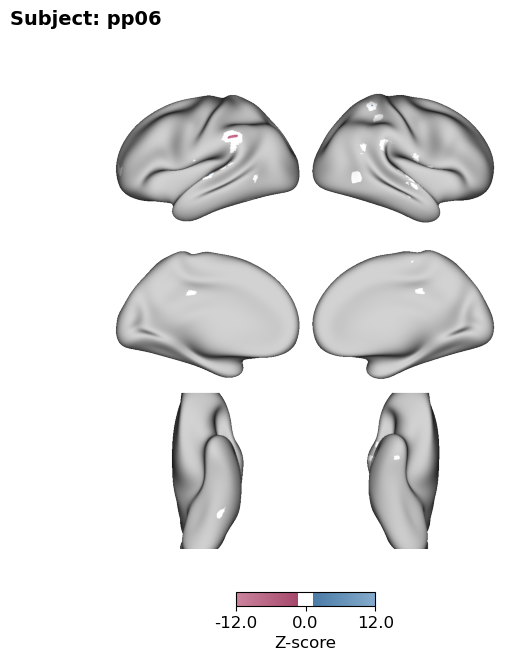

In [6]:
dark_rose  = (0.65, 0.28, 0.42)
bright_rose = (0.80, 0.52, 0.62)
dark_blue  = (0.29, 0.48, 0.65)
bright_blue = (0.52, 0.67, 0.80)

cdict = {
    "red":   [(0.0, bright_rose[0], bright_rose[0]),
              (0.45, dark_rose[0], 1.0),
              (0.55, 1.0, dark_blue[0]),
              (1.0, bright_blue[0], bright_blue[0])],
    "green": [(0.0, bright_rose[1], bright_rose[1]),
              (0.45, dark_rose[1], 1.0),
              (0.55, 1.0, dark_blue[1]),
              (1.0, bright_blue[1], bright_blue[1])],
    "blue":  [(0.0, bright_rose[2], bright_rose[2]),
              (0.45, dark_rose[2], 1.0),
              (0.55, 1.0, dark_blue[2]),
              (1.0, bright_blue[2], bright_blue[2])]
}
cmap_custom = LinearSegmentedColormap("custom_diverging", cdict)

kws = {"location": "bottom",
       "label_direction": 0,
       "fontsize": 12,
       "aspect": 10,
       "draw_border": True}

display = Display(visible=0, size=(1024, 768))
display.start()

try:
    lh, rh = surfaces["inflated"]
    p = Plot(surf_lh=lh, surf_rh=rh, views=["lateral", "medial", "ventral"],
             size=(500, 600), brightness=0.6)
    p.add_layer(
        {"left": fslr_lh_data, "right": fslr_rh_data},
        cmap=cmap_custom,
        color_range=(-z_max, z_max) if stat == "z_score" else None
    )
    fig = p.build(cbar_kws=kws)

    fig.text(
        0.02, 0.98,
        f"Subject: {subject}",
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold"
    )

    for ax in fig.axes:
        if hasattr(ax, "get_xlabel"):
            ax.set_xlabel("Z-score" if stat == "z_score" else "Effect size", fontsize=12)

    surface_fn = join(output_dir, f"{sub}_task-{task}_{map_kind}-{map_name}_stat-{stat}_surface.svg")
    fig.savefig(surface_fn, bbox_inches="tight")
finally:
    display.stop()

print(surface_fn)